# Project 14: The Most Likely Alloy Is Not the Most Trustworthy Alloy — Fatigue Prediction Beyond MLE
#### Submitted by   MUSULURU  JEEVAN RAGHA SOURYA - MS25MTECH11002

### What I did?

* Performed **MLE** and plotted the Basquin straight-line fit in log–log space.
* Performed **Bayesian regression** on the same Basquin model using the PyMC library, with physics-informed priors for Ti-6Al-4V (referred ChatGPT and internet for these prior values).
* Extended the analysis with **Gaussian Process Regression (GPR)** Used an RBF kernel with a constrained length-scale plus a WhiteKernel for noise to avoid overfitting.
* Compared all three methods side-by-side and as an overlay on the same log–log axes.

### Observations 

* **MLE** gives one straight line ,looks confident but shows no uncertainty.
* **Bayesian** gives a distribution of straight lines . uncertainty in slope and intercept is visible, but the variance in the lines is very small because of widely spread points.
* **GPR** is the most honest of the three . uncertainty bands have covered wider range.

### Doubts

* How can i know wether the gpr result is overfitting or underfitting? .
* how to validate the results?.

### AI Acknowledgement
* Used AI to understand the code given for data cleaning and subset making.
* Used AI to assume some physically valied priors for bayesian regression.
* Used AI to learm about the features of PYMC, Arviz an Scikit-Learn.
* As I dont know how to use the libraries i asked AI to generate code base on the requirements and I matched the names of the variables.
* All the parameters of the funtions of above stated libraries, while declaring i have taken the help of ai, to undertsand them and tweak them.
* Giving an old version of this note book as input , asked the AI to write coloums for plotting graphs (side by side and the overlay versions).
* In the end, asked AI to properly format the note book.



## Objective
In this project, we investigate a serious statistical and scientific issue in fatigue modeling:

A single best-fit relation may look precise, even when the data do not support that level of certainty.

We work with a real subset of the **FatigueData-AM2022** database, which contains fatigue data and linked metadata for additively manufactured alloys. The broader database includes S–N, ε–N, and da/dN–ΔK data, together with information about materials, AM route, processing, testing, and static mechanical properties.

For this project, we deliberately use only a **subset** of the database so that the scientific question stays sharp. We focus on:
- **S–N data**
- one alloy family, typically **Ti–6Al–4V**
- optionally one AM route such as **L-PBF**
- and a small set of comparable descriptors

## Why this is scientifically interesting
The FatigueData-AM2022 paper makes two points that are crucial here:

1. fatigue data from the literature are often **highly scattered**,
2. and they can also show **system deviation** because fabrication, specimen preparation, surface condition, and testing standards vary across studies.

That means a point-estimate approach such as maximum likelihood estimation (MLE) can easily appear more certain than it should.

A fitted line may look clean. A best-fit trend may look convincing. But in a heterogeneous fatigue dataset, that apparent certainty may be misleading.

## The scientific puzzle
We want to model fatigue behavior using a manageable subset of real S–N data.

The danger is this:

> If we use only an MLE-style best fit, do we get a trend that looks precise but hides how uncertain, study-dependent, or data-sparse the inference really is?

The alternative is **Bayesian regression**, which does not give only one best answer. Instead, it gives a **distribution over plausible parameter values and predictions**.

So the central question is not just:

> What is the best-fit fatigue trend?

but rather:

> How trustworthy is that trend once uncertainty is treated honestly?

## What this notebook does
This notebook begins by extracting a clean subset from the real fatigue database:
- S–N data only,
- one alloy family,
- optionally one AM route,
- and only rows with the metadata needed for a meaningful regression problem.

It then prepares a dataset for modeling fatigue life as a function of stress amplitude and selected process/testing descriptors.

The notebook does **not** yet perform the final Bayesian regression. It sets up the subset cleanly and shows why a point-estimate mindset may be risky.
In other words, this project is not merely about prediction. It is about **how much trust we should place in the inferred fatigue law**.

## What to look for
As you inspect the subset, ask:

- How much scatter is present even after subsetting?
- Do some datasets appear dense while others are sparse?
- Are there signs that a single best-fit trend may be too confident?
- If two regions have similar fitted mean behavior, do they also have similar uncertainty?
- Does a Bayesian treatment change the process/design recommendation?

This project is therefore about **fatigue data heterogeneity, the danger of overconfident MLE-style inference, and why Bayesian regression may be the more honest model in a scattered real-data setting**.

Raw sheet shapes:
S-N: (15146, 4)
parameter: (2460, 47)

Cleaned S-N columns:
['dataset_id', 'life_n_cycle', 'stress_amplitude_σa_mpa', 'runout']

Cleaned parameter columns:
['dataset_id', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mms', 'hatch_space_μm', 'layer_thickness_μm', 'preheat_temperature_c', 'direciton_of_specimen_', 'am_environment', 'scan_pattern', 'layer_scan_rotation_', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_gs', 'wire_feed_rate_mms', 'types_of_feedstock', 'size_of_feedstock_μm', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimens

,dataset_id,life_N,stress_amplitude_MPa,runout,material,am_type,load_ratio
0,1,20047.798627,233.965265,0,316L,L-PBF,0.1
1,1,50630.187289,215.905854,0,316L,L-PBF,0.1
2,1,94372.343349,197.999439,0,316L,L-PBF,0.1
3,1,152595.813892,180.016661,0,316L,L-PBF,0.1
4,1,270549.972140,161.845026,0,316L,L-PBF,0.1



Subset shape after filtering: (3749, 11)
Unique datasets in subset: 385


,dataset_id,life_N,stress_amplitude_MPa,runout,material,am_type,load_ratio,material_str,am_type_str,load_ratio_num,log10_life_N
12,3,14289.371370,403.214603,0,Ti-6Al-4V,L-PBF,-1,ti-6al-4v,l-pbf,-1.0,4.155013
13,3,27333.086531,368.095592,0,Ti-6Al-4V,L-PBF,-1,ti-6al-4v,l-pbf,-1.0,4.436689
14,3,37580.333506,368.095592,0,Ti-6Al-4V,L-PBF,-1,ti-6al-4v,l-pbf,-1.0,4.574961
15,3,65344.319692,309.024583,0,Ti-6Al-4V,L-PBF,-1,ti-6al-4v,l-pbf,-1.0,4.815208
16,3,67384.073870,308.889990,0,Ti-6Al-4V,L-PBF,-1,ti-6al-4v,l-pbf,-1.0,4.828557



Top dataset sizes:


,dataset_id,n_points
239,1019,34
173,686,25
176,689,24
215,871,24
131,509,23
36,220,22
143,541,22
214,850,21
362,1471,21
172,685,20


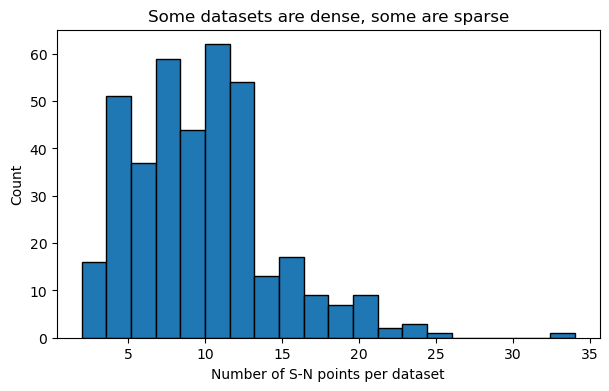

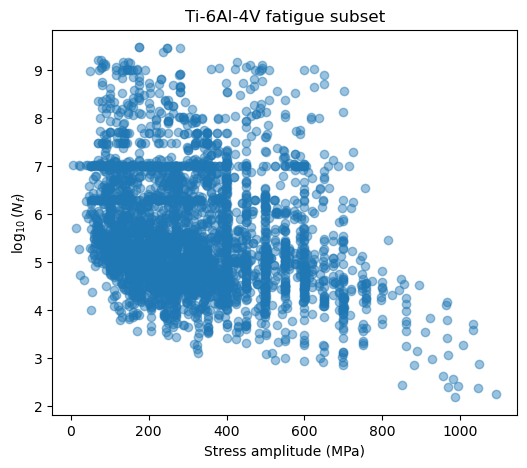

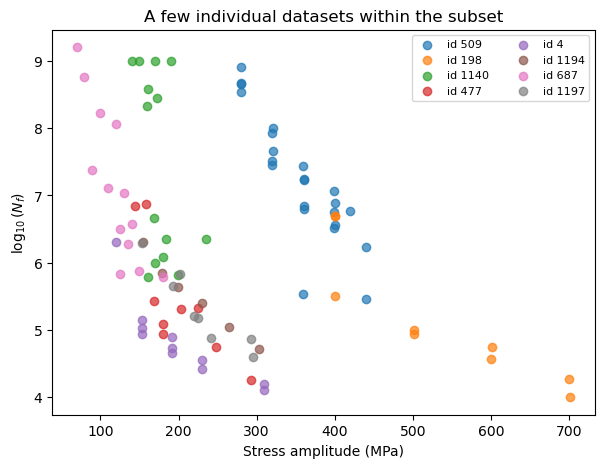


OLS coefficients (intercept, slope):
[ 6.10847085e+00 -1.73150193e-03]


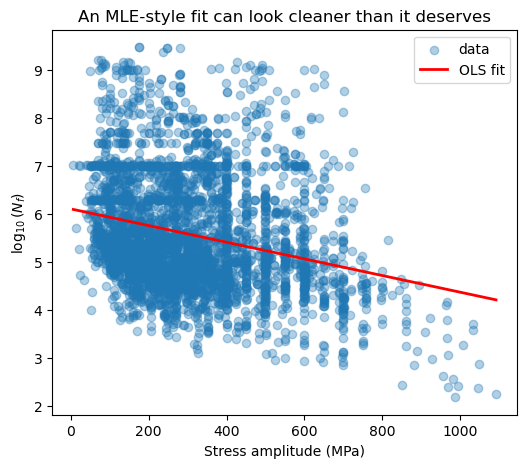

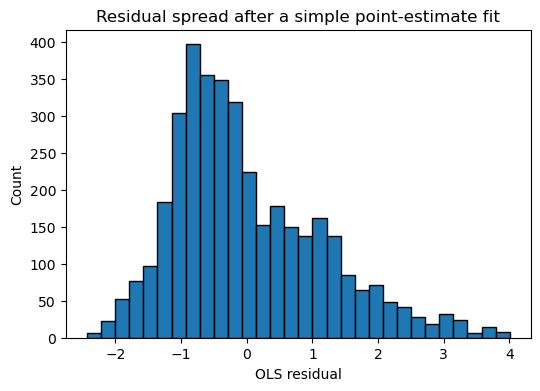


Questions to think about:
1. After subsetting, how much scatter still remains in the S-N data?
2. Do some datasets dominate the subset while others remain sparse?
3. Does the OLS best-fit line look more certain than the data really justify?
4. If process or study effects are still present, what is a single best-fit line missing?
5. Why might Bayesian regression be more honest than MLE in this setting?


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

xlsx_path = Path("./FatigueData-AM2022.xlsx")

# S-N sheet is normal
sn = pd.read_excel(xlsx_path, sheet_name="S-N")

# parameter sheet needs the second row as header
param = pd.read_excel(xlsx_path, sheet_name="parameter", header=1)

print("Raw sheet shapes:")
print("S-N:", sn.shape)
print("parameter:", param.shape)


def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^\w_]+", "", regex=True)
    )
    return df


sn = clean_cols(sn)
param = clean_cols(param)

print("\nCleaned S-N columns:")
print(sn.columns.tolist())

print("\nCleaned parameter columns:")
print(param.columns.tolist())


def find_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


sn_id_col = find_col(sn.columns, ["dataset_id", "datasetid", "id"])
param_id_col = find_col(param.columns, ["dataset_id", "datasetid", "id"])

life_col = find_col(sn.columns, [
    "life_n_cycle", "life_n_cycles", "life_n", "n_cycle", "n_cycles", "life"
])

stress_col = find_col(sn.columns, [
    "stress_amplitude_σa_mpa",
    "stress_amplitude_a_mpa",
    "stress_amplitude_mpa",
    "stress_amplitude",
    "sigmaa_mpa",
    "sigma_a",
    "sigmaa"
])

runout_col = find_col(sn.columns, ["runout", "run_out", "runout_flag"])

material_col = find_col(param.columns, [
    "mat_name", "material_name", "material", "alloy", "name_of_the_material"
])

am_type_col = find_col(param.columns, [
    "am_type", "types_of_am", "am_process", "amroute"
])

load_ratio_col = find_col(param.columns, [
    "fat_r", "load_ratio", "stress_ratio", "r"
])

fatigue_type_col = find_col(param.columns, [
    "fat_type", "type_of_fatigue_tests", "fatigue_type"
])

frequency_col = find_col(param.columns, [
    "frequency", "fatigue_frequency"
])

surface_col = find_col(param.columns, [
    "surface_treatment", "surface", "surf_method", "method"
])

print("\nDetected columns:")
print("sn_id_col       :", sn_id_col)
print("param_id_col    :", param_id_col)
print("life_col        :", life_col)
print("stress_col      :", stress_col)
print("runout_col      :", runout_col)
print("material_col    :", material_col)
print("am_type_col     :", am_type_col)
print("load_ratio_col  :", load_ratio_col)
print("fatigue_type_col:", fatigue_type_col)
print("frequency_col   :", frequency_col)
print("surface_col     :", surface_col)

if sn_id_col is None or param_id_col is None:
    raise ValueError("Could not identify dataset-id columns in both sheets.")

if life_col is None or stress_col is None:
    raise ValueError("Could not identify fatigue-life and stress-amplitude columns in S-N sheet.")

if material_col is None:
    raise ValueError("Could not identify material-name column in parameter sheet.")


sn_keep = [c for c in [sn_id_col, life_col, stress_col, runout_col] if c is not None]
param_keep = [c for c in [
    param_id_col, material_col, am_type_col, load_ratio_col,
    fatigue_type_col, frequency_col, surface_col
] if c is not None]

sn_sub = sn[sn_keep].copy()
param_sub = param[param_keep].copy()

rename_sn = {
    sn_id_col: "dataset_id",
    life_col: "life_N",
    stress_col: "stress_amplitude_MPa",
}
if runout_col is not None:
    rename_sn[runout_col] = "runout"

rename_param = {
    param_id_col: "dataset_id",
    material_col: "material",
}
if am_type_col is not None:
    rename_param[am_type_col] = "am_type"
if load_ratio_col is not None:
    rename_param[load_ratio_col] = "load_ratio"
if fatigue_type_col is not None:
    rename_param[fatigue_type_col] = "fatigue_type"
if frequency_col is not None:
    rename_param[frequency_col] = "frequency"
if surface_col is not None:
    rename_param[surface_col] = "surface_info"

sn_sub = sn_sub.rename(columns=rename_sn)
param_sub = param_sub.rename(columns=rename_param)

merged = sn_sub.merge(param_sub, on="dataset_id", how="left")

print("\nMerged shape:", merged.shape)
display(merged.head())

subset = merged.copy()
subset["material_str"] = subset["material"].astype(str).str.lower()

ti_mask = subset["material_str"].str.contains(
    "ti-6al-4v|ti64|ti 6al 4v",
    regex=True,
    na=False
)
subset = subset[ti_mask].copy()

use_l_pbf_only = True
if "am_type" in subset.columns and use_l_pbf_only:
    subset["am_type_str"] = subset["am_type"].astype(str).str.lower()
    subset = subset[
        subset["am_type_str"].str.contains(
            "l-pbf|lpbf|laser_powder_bed_fusion|laser powder bed fusion",
            regex=True,
            na=False
        )
    ].copy()

if "fatigue_type" in subset.columns:
    subset["fatigue_type_str"] = subset["fatigue_type"].astype(str).str.lower()
    subset = subset[
        subset["fatigue_type_str"].str.contains(
            "uniaxial|bending",
            regex=True,
            na=False
        )
    ].copy()

use_R_minus_1_only = False
if "load_ratio" in subset.columns:
    subset["load_ratio_num"] = pd.to_numeric(subset["load_ratio"], errors="coerce")
    if use_R_minus_1_only:
        subset = subset[
            np.isclose(subset["load_ratio_num"], -1.0, atol=0.15, equal_nan=False)
        ].copy()

subset["life_N"] = pd.to_numeric(subset["life_N"], errors="coerce")
subset["stress_amplitude_MPa"] = pd.to_numeric(subset["stress_amplitude_MPa"], errors="coerce")

if "runout" in subset.columns:
    subset["runout"] = pd.to_numeric(subset["runout"], errors="coerce")

if "frequency" in subset.columns:
    subset["frequency_num"] = pd.to_numeric(subset["frequency"], errors="coerce")

subset = subset.dropna(subset=["dataset_id", "life_N", "stress_amplitude_MPa"])
subset = subset[(subset["life_N"] > 0) & (subset["stress_amplitude_MPa"] > 0)].copy()
subset["log10_life_N"] = np.log10(subset["life_N"])

print("\nSubset shape after filtering:", subset.shape)
print("Unique datasets in subset:", subset["dataset_id"].nunique())
display(subset.head())

dataset_counts = (
    subset.groupby("dataset_id")
    .size()
    .reset_index(name="n_points")
    .sort_values("n_points", ascending=False)
)

print("\nTop dataset sizes:")
display(dataset_counts.head(10))

plt.figure(figsize=(7, 4))
plt.hist(dataset_counts["n_points"], bins=20, edgecolor="black")
plt.xlabel("Number of S-N points per dataset")
plt.ylabel("Count")
plt.title("Some datasets are dense, some are sparse")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(
    subset["stress_amplitude_MPa"],
    subset["log10_life_N"],
    alpha=0.45
)
plt.xlabel("Stress amplitude (MPa)")
plt.ylabel(r"$\log_{10}(N_f)$")
plt.title("Ti-6Al-4V fatigue subset")
plt.show()

unique_ids = subset["dataset_id"].dropna().unique()
rng = np.random.default_rng(2034)
sample_ids = rng.choice(unique_ids, size=min(8, len(unique_ids)), replace=False)

plt.figure(figsize=(7, 5))
for did in sample_ids:
    sub = subset[subset["dataset_id"] == did]
    plt.scatter(
        sub["stress_amplitude_MPa"],
        sub["log10_life_N"],
        alpha=0.7,
        label=f"id {did}"
    )

plt.xlabel("Stress amplitude (MPa)")
plt.ylabel(r"$\log_{10}(N_f)$")
plt.title("A few individual datasets within the subset")
plt.legend(fontsize=8, ncol=2)
plt.show()

X = np.column_stack([np.ones(len(subset)), subset["stress_amplitude_MPa"].values])
y = subset["log10_life_N"].values

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_pred = X @ beta
resid = y - y_pred

subset["ols_pred"] = y_pred
subset["ols_resid"] = resid

print("\nOLS coefficients (intercept, slope):")
print(beta)

plt.figure(figsize=(6, 5))
plt.scatter(subset["stress_amplitude_MPa"], subset["log10_life_N"], alpha=0.35, label="data")
order = np.argsort(subset["stress_amplitude_MPa"].values)
plt.plot(
    subset["stress_amplitude_MPa"].values[order],
    subset["ols_pred"].values[order],
    color="red",
    lw=2,
    label="OLS fit"
)
plt.xlabel("Stress amplitude (MPa)")
plt.ylabel(r"$\log_{10}(N_f)$")
plt.title("An MLE-style fit can look cleaner than it deserves")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(subset["ols_resid"], bins=30, edgecolor="black")
plt.xlabel("OLS residual")
plt.ylabel("Count")
plt.title("Residual spread after a simple point-estimate fit")
plt.show()

print("\nQuestions to think about:")
print("1. After subsetting, how much scatter still remains in the S-N data?")
print("2. Do some datasets dominate the subset while others remain sparse?")
print("3. Does the OLS best-fit line look more certain than the data really justify?")
print("4. If process or study effects are still present, what is a single best-fit line missing?")
print("5. Why might Bayesian regression be more honest than MLE in this setting?")

## Task

The opening notebook extracts a manageable real-data subset from the FatigueData-AM2022 database and prepares it for fatigue-life modeling.

Your task is to analyze this subset using a **physics-informed Basquin-type S–N relation in log–log form**, rather than an arbitrary regression curve. In particular, you should work with a model of the form

$$
\sigma_a = A N^B
$$

or equivalently,

$$
\log \sigma_a = \log A + B \log N.
$$

You should then compare two inferential approaches applied to the **same log–log fatigue-law model**:

- a **maximum-likelihood estimate (MLE)** of the fatigue-law parameters,
- and a **Bayesian inference** of the same fatigue-law parameters.

The purpose of the project is not merely to obtain a fitted trend. It is to examine whether a single best-fit fatigue law may appear more certain than the data really justify, and whether a Bayesian treatment changes that picture once uncertainty is made explicit.

In your analysis, you should ask:
- how much scatter remains even after careful subsetting,
- whether the fitted fatigue-law parameters are stable or uncertain,
- how the MLE fit and Bayesian fit differ in their predictive implications,
- and whether a process or design recommendation based on the MLE fit remains trustworthy once posterior uncertainty is taken into account.

A strong submission will not compare Bayesian inference only against a crude straight-line baseline. It will compare **MLE and Bayesian inference using the same physically motivated log–log fatigue-law model**, and then interpret the difference between point-estimate confidence and uncertainty-aware inference.

The central scientific question is:

> When the same log–log fatigue physics model is used, does the best-fit MLE tell the whole story, or does Bayesian inference reveal that the apparent trend is much less certain than it first appears?

In [3]:
# ── Basquin log-log preparation ───────────────────────────────────────────────
# True Basquin model:  log10(sigma_a) = log10(A) + B * log10(Nf)
# So: x = log10(Nf),  y = log10(sigma_a)

subset["log10_stress"] = np.log10(subset["stress_amplitude_MPa"])


x = subset["log10_life_N"].values     # independent variable
y = subset["log10_stress"].values     # dependent variable

print(f"Data ready: {len(x)} points")
print(f"  x = log10(Nf)    range: {x.min():.2f} to {x.max():.2f}")
print(f"  y = log10(sigma) range: {y.min():.2f} to {y.max():.2f}")


Data ready: 3749 points
  x = log10(Nf)    range: 2.19 to 9.48
  y = log10(sigma) range: 0.76 to 3.04


 ### MLE with Basquin Equation

Basquin Equation:
$$\log_{10}(\sigma_a) = \log_{10}(A) + B \cdot \log_{10}(N_f)$$

 
**x = log₁₀(Nf)** (life, independent),  **y = log₁₀(σa)** (stress, dependent)


MLE — Basquin log-log fit
  log10(A) = 2.7236   →  A = 529.14 MPa
  B        = -0.0550
  noise σ̂  = 0.2574 log10(MPa)


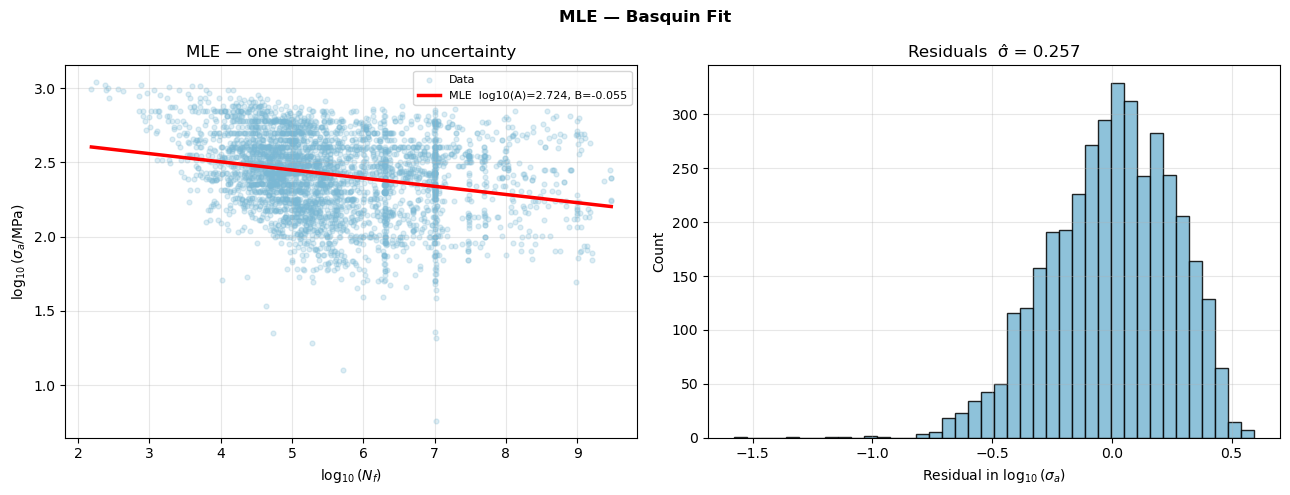

In [4]:
# ── MLE: OLS on the true Basquin model ───────────────────────────────────────
X_mat = np.column_stack([np.ones(len(x)), x])
beta_mle, *_ = np.linalg.lstsq(X_mat, y, rcond=None)
log10_A, B_basquin = beta_mle

resid_mle = y - X_mat @ beta_mle
sigma_mle = np.std(resid_mle, ddof=2)

print("=" * 50)
print("MLE — Basquin log-log fit")
print(f"  log10(A) = {log10_A:.4f}   →  A = {10**log10_A:.2f} MPa")
print(f"  B        = {B_basquin:.4f}")
print(f"  noise σ̂  = {sigma_mle:.4f} log10(MPa)")
print("=" * 50)

# Prediction line over full data range
x_line = np.linspace(x.min(), x.max(), 300)
y_mle  = log10_A + B_basquin * x_line

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("MLE — Basquin Fit", fontsize=12, fontweight="bold")

ax = axes[0]
ax.scatter(x, y, alpha=0.25, s=12, color="#7ab8d4", label="Data")
ax.plot(x_line, y_mle, color="red", lw=2.5,
        label=f"MLE  log10(A)={log10_A:.3f}, B={B_basquin:.3f}")
ax.set_xlabel(r"$\log_{10}(N_f)$")
ax.set_ylabel(r"$\log_{10}(\sigma_a / \mathrm{MPa})$")
ax.set_title("MLE — one straight line, no uncertainty")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(resid_mle, bins=40, edgecolor="black", color="#7ab8d4", alpha=0.85)
ax.set_xlabel(r"Residual in $\log_{10}(\sigma_a)$")
ax.set_ylabel("Count")
ax.set_title(f"Residuals  σ̂ = {sigma_mle:.3f}")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Bayesian with Basquin model using PyMC

Same model as MLE:
$$\log_{10}(\sigma_a) = \log_{10}(A) + B \cdot \log_{10}(N_f)$$

Parameters are now **inferred as full distributions** via MCMC (NUTS sampler).

**Priors are  physics-informed for Ti-6Al-4V:**
- $\log_{10}(A) \sim \mathcal{N}(3.0,\, 0.5^2)$  
  At $N_f = 1$, stress = A ≈ 1000–2000 MPa for Ti-6Al-4V → log10(A) ≈ 3.0–3.3
- $B \sim \mathcal{N}(-0.1,\, 0.05^2)$  
  Literature Basquin exponent for Ti-6Al-4V: typically −0.07 to −0.12
- $\sigma \sim \text{HalfNormal}(0.5)$  
  Scatter in log10(stress) — must be positive, expected < 0.5


In [5]:
import pymc as pm
import arviz as az

# Centre x for numerical stability
x_mean = x.mean()
xc     = x - x_mean

with pm.Model() as basquin_model:
    # ── Priors ───────────────────────────────────────────────────────────────
    log10_A_rv = pm.Normal("log10_A", mu=3.0,  sigma=0.5)
    B_rv       = pm.Normal("B",       mu=-0.1, sigma=0.05)
    stress_noise_rv = pm.HalfNormal("stress_noise", sigma=0.5)

    # ── Likelihood ───────────────────────────────────────────────────────────
    mu  = (log10_A_rv + B_rv * x_mean) + B_rv * xc
    obs = pm.Normal("obs", mu=mu, sigma=stress_noise_rv, observed=y)

    # ── Sampling ─────────────────────────────────────────────────────────────
    trace = pm.sample(2000, tune=2000, chains=4, cores=1,
                      target_accept=0.9, random_seed=42,
                      return_inferencedata=True)

# ── Summary ─────────────────────────────────────────────────────────────────
print(az.summary(trace, var_names=["log10_A", "B", "stress_noise"]))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [log10_A, B, stress_noise]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 37 seconds.


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log10_A       2.726  0.020   2.688    2.763        0.0      0.0    2566.0   
B            -0.055  0.004  -0.062   -0.049        0.0      0.0    2543.0   
stress_noise  0.257  0.003   0.252    0.263        0.0      0.0    3770.0   

              ess_tail  r_hat  
log10_A         2902.0    1.0  
B               2924.0    1.0  
stress_noise    3448.0    1.0  


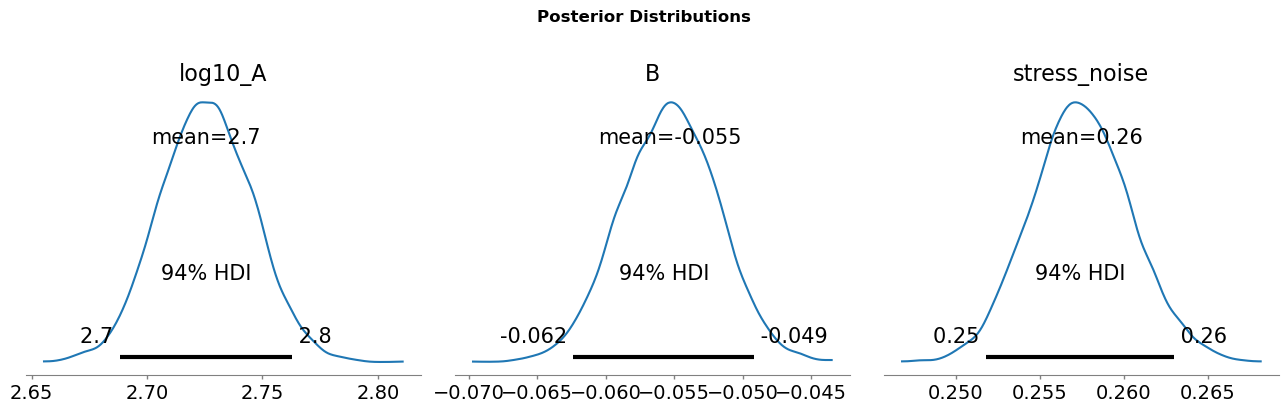

In [6]:
az.plot_posterior(trace, var_names=["log10_A", "B", "stress_noise"], figsize=(13, 4))
plt.suptitle("Posterior Distributions", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("posterior distribution.png")
plt.show()


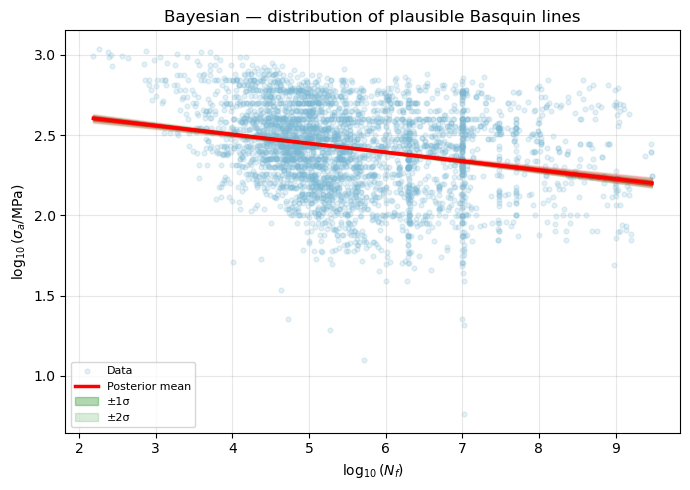

In [7]:
# ── Posterior predictive lines ────────────────────────────────────────────────
post          = trace.posterior
log10_A_samps = post["log10_A"].values.flatten()
B_samps       = post["B"].values.flatten()

# Posterior lines on the same x_line used for MLE
lines      = np.array([log10_A_samps[i] + B_samps[i] * x_line
                        for i in range(len(log10_A_samps))])
bayes_mean = lines.mean(axis=0)
bayes_std  = lines.std(axis=0)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.2, s=12, color="#7ab8d4", label="Data")
for line in lines[::80]:
    plt.plot(x_line, line, color="red", alpha=0.04, lw=1)
plt.plot(x_line, bayes_mean, color="red", lw=2.5, label="Posterior mean")
plt.fill_between(x_line, bayes_mean - bayes_std, bayes_mean + bayes_std,
                 alpha=0.30, color="green", label="\u00b11\u03c3")
plt.fill_between(x_line, bayes_mean - 2*bayes_std, bayes_mean + 2*bayes_std,
                 alpha=0.15, color="green", label="\u00b12\u03c3")
plt.xlabel(r"$\log_{10}(N_f)$")
plt.ylabel(r"$\log_{10}(\sigma_a / \mathrm{MPa})$")
plt.title("Bayesian — distribution of plausible Basquin lines")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bayesian_fit.png", dpi=300, bbox_inches="tight")
plt.show()


### Gaussian Process Regression (GPR)

GPR is a **non-parametric Bayesian method**. It does not assume the Basquin straight line — it lets the data decide the curve shape.

Same axes as MLE and Bayesian:
- **x = log₁₀(Nf)** — life (independent)
- **y = log₁₀(σa)** — stress (dependent)

Kernel: **RBF** (smoothness) + **WhiteKernel** (observation noise).  
Length-scale constrained to ≥ 0.5 to prevent overfitting through every cluster.


Optimised kernel: 0.499**2 * RBF(length_scale=1.12) + WhiteKernel(noise_level=0.902)


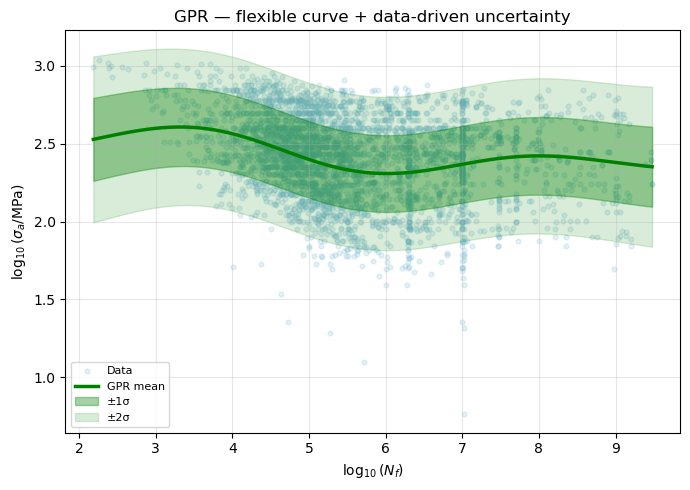

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

# Subsample 400 points for speed — GPR is O(n³)
rng_gpr = np.random.default_rng(42)
idx_gpr = rng_gpr.choice(len(subset), size=min(400, len(subset)), replace=False)

# x = log10(Nf),  y = log10(stress) — same Basquin convention
x_gpr = x[idx_gpr].reshape(-1, 1)
y_gpr = y[idx_gpr]

# Normalise for numerical stability
x_mu, x_sd = x_gpr.mean(), x_gpr.std()
y_mu, y_sd = y_gpr.mean(), y_gpr.std()
xn = (x_gpr - x_mu) / x_sd
yn = (y_gpr - y_mu) / y_sd

# Constrained kernel — minimum length-scale prevents wiggly overfitting
kernel = ((C(1.0, (1e-3, 10))) * RBF(length_scale=0.5, length_scale_bounds=(1.0, 8.0)) + WhiteKernel(noise_level=0.3, noise_level_bounds=(0.05, 1.5)))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                random_state=0, normalize_y=False)
gpr.fit(xn, yn)
print("Optimised kernel:", gpr.kernel_)

# Predict on the same x_line used for MLE and Bayesian
xn_grid = (x_line.reshape(-1, 1) - x_mu) / x_sd
mu_n, std_n = gpr.predict(xn_grid, return_std=True)
mu_gpr  = mu_n  * y_sd + y_mu    # back to log10(stress) scale
std_gpr = std_n * y_sd

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.2, s=12, color="#7ab8d4", label="Data")
plt.plot(x_line, mu_gpr, color="green", lw=2.5, label="GPR mean")
plt.fill_between(x_line, mu_gpr - std_gpr, mu_gpr + std_gpr,
                 alpha=0.35, color="green", label="\u00b11\u03c3")
plt.fill_between(x_line, mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                 alpha=0.15, color="green", label="\u00b12\u03c3")
plt.xlabel(r"$\log_{10}(N_f)$")
plt.ylabel(r"$\log_{10}(\sigma_a / \mathrm{MPa})$")
plt.title("GPR — flexible curve + data-driven uncertainty")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gpr_fit.png", dpi=300, bbox_inches="tight")
plt.show()


### Comparison Plots

All three methods on the same axes:  
**x = log₁₀(Nf)**, **y = log₁₀(σa)** — true Basquin convention throughout.


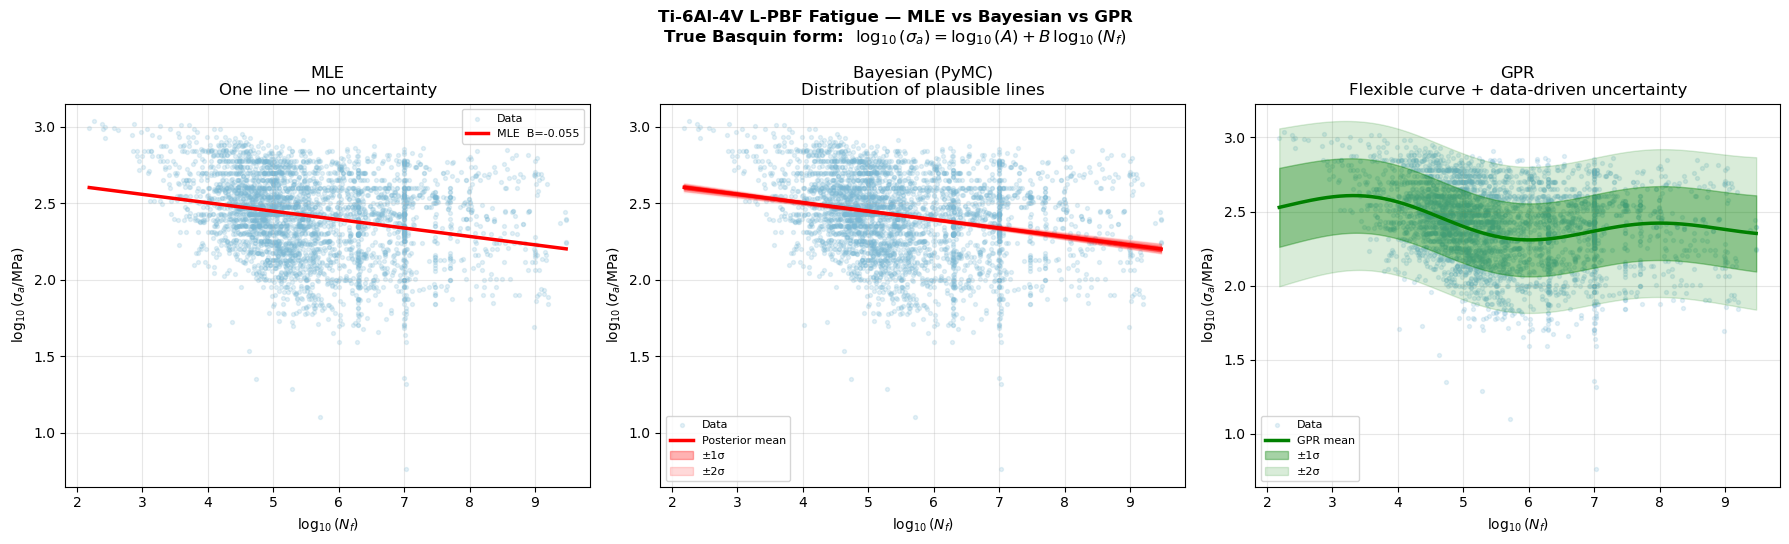

In [9]:
# ── Side-by-side: MLE | Bayesian | GPR ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    "Ti-6Al-4V L-PBF Fatigue — MLE vs Bayesian vs GPR\n"
    r"True Basquin form:  $\log_{{10}}(\sigma_a) = \log_{{10}}(A) + B\,\log_{{10}}(N_f)$",
    fontsize=12, fontweight="bold"
)

# ── MLE ───────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(x, y, alpha=0.2, s=8, color="#7ab8d4", label="Data")
ax.plot(x_line, y_mle, color="red", lw=2.5,
        label=f"MLE  B={B_basquin:.3f}")
ax.set_xlabel(r"$\log_{{10}}(N_f)$")
ax.set_ylabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_title("MLE\nOne line — no uncertainty")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Bayesian ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(x, y, alpha=0.2, s=8, color="#7ab8d4", label="Data", zorder=1)
for line in lines[::80]:
    ax.plot(x_line, line, color="red", alpha=0.04, lw=1, zorder=2)
ax.plot(x_line, bayes_mean, color="red", lw=2.5, label="Posterior mean", zorder=3)
ax.fill_between(x_line, bayes_mean - bayes_std, bayes_mean + bayes_std,
                alpha=0.30, color="red", label="\u00b11\u03c3", zorder=3)
ax.fill_between(x_line, bayes_mean - 2*bayes_std, bayes_mean + 2*bayes_std,
                alpha=0.15, color="red", label="\u00b12\u03c3", zorder=3)
ax.set_xlabel(r"$\log_{{10}}(N_f)$")
ax.set_ylabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_title("Bayesian (PyMC)\nDistribution of plausible lines")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── GPR ───────────────────────────────────────────────────────────────────────
ax = axes[2]
ax.scatter(x, y, alpha=0.2, s=8, color="#7ab8d4", label="Data", zorder=1)
ax.plot(x_line, mu_gpr, color="green", lw=2.5, label="GPR mean", zorder=3)
ax.fill_between(x_line, mu_gpr - std_gpr, mu_gpr + std_gpr,
                alpha=0.35, color="green", label="\u00b11\u03c3", zorder=2)
ax.fill_between(x_line, mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                alpha=0.15, color="green", label="\u00b12\u03c3", zorder=2)
ax.set_xlabel(r"$\log_{{10}}(N_f)$")
ax.set_ylabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_title("GPR\nFlexible curve + data-driven uncertainty")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("side_fit.png", dpi=300, bbox_inches="tight")
plt.show()


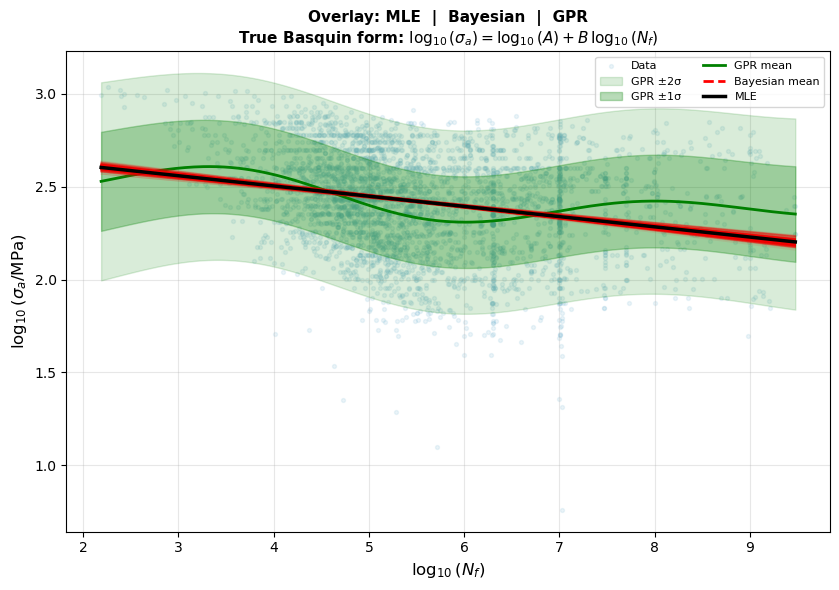

In [10]:
# ── Overlay all three on one axes ─────────────────────────────────────────────
plt.figure(figsize=(8.5, 6))
# Data
plt.scatter(x, y, alpha=0.15, s=8, color="#7ab8d4", label="Data", zorder=1)
# GPR bands (back)
plt.fill_between(x_line, mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                 alpha=0.15, color="green", label="GPR \u00b12\u03c3", zorder=2)
plt.fill_between(x_line, mu_gpr - std_gpr, mu_gpr + std_gpr,
                 alpha=0.28, color="green", label="GPR \u00b11\u03c3", zorder=3)
plt.plot(x_line, mu_gpr, color="green", lw=2, label="GPR mean", zorder=4)
# Bayesian
for line in lines[::20]:
    plt.plot(x_line, line, color="red", alpha=0.08, lw=0.8, zorder=5)
plt.plot(x_line, bayes_mean, color="red", lw=2, ls="--",
         label="Bayesian mean", zorder=6)
# MLE on top
plt.plot(x_line, y_mle, color="black", lw=2.5, label="MLE", zorder=7)
plt.xlabel(r"$\log_{10}(N_f)$", fontsize=12)
plt.ylabel(r"$\log_{10}(\sigma_a / \mathrm{MPa})$", fontsize=12)
plt.title("Overlay: MLE  |  Bayesian  |  GPR\n"
          r"True Basquin form: $\log_{{10}}(\sigma_a) = \log_{{10}}(A) + B\,\log_{{10}}(N_f)$",
          fontsize=11, fontweight="bold")
plt.legend(fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("overlay_mle_bayesian_gpr.png", dpi=300, bbox_inches="tight")
plt.show()

## GPR training and testing by splitting the data (Kernels : RBF , Polinomial)

### Suggested Improvement


## Training–Testing Procedure

- The total dataset (385 datasets) was split into an **80:20 ratio** for training and testing.  
- The split was performed by **randomly shuffling dataset IDs**, ensuring that entire datasets remain grouped together.  
- **80% of the datasets** were used for training, while the remaining **20% were reserved for testing**.  
- The splitting, training, and testing process was repeated for **two independent iterations** to assess robustness.  

## Model Training

- Two Gaussian Process Regression (GPR) models were trained:  
  - **RBF kernel** (captures smooth, local variations)  
  - **Polynomial kernel** (captures global, Basquin-like trends)  
- The workflow was implemented in a loop such that:  
  - each iteration uses a **new random train–test split**,  
  - models are **retrained from scratch**,  
  - kernel hyperparameters are **re-optimized in each iteration**.  

## Model Evaluation

- Model performance was evaluated using **Root Mean Square Error (RMSE)**.  
- RMSE was computed for both:  
  - training data (to assess fit quality)  
  - testing data (to assess generalization performance)  
- RMSE values were calculated for **both kernels across both iterations**, enabling comparison of model stability and predictive accuracy.
- This approach ensures that results are not dependent on a single data split and provides a more reliable comparison between kernel choices.


 ITERATION 1 - RESTARTING TRAINING DATA SPLIT
 
Optimized Kernels:
 
RBF Kernel        -> 0.474**2 * RBF(length_scale=1.09) + WhiteKernel(noise_level=0.859)
 
Polynomial Kernel -> 0.167**2 * DotProduct(sigma_0=1.15) ** 2 + WhiteKernel(noise_level=0.87)

 RBF Kernel        -> Train RMSE: 0.2423 | Test RMSE: 0.2899

 Polynomial Kernel -> Train RMSE: 0.2413 | Test RMSE: 0.2922



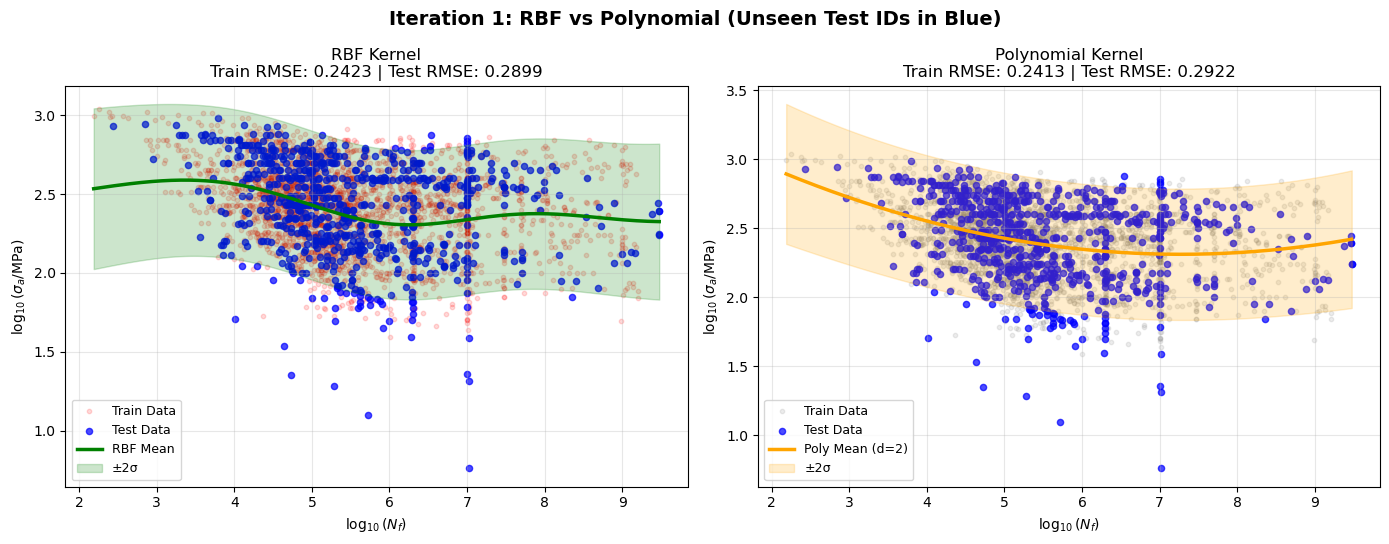


 ITERATION 2 - RESTARTING TRAINING DATA SPLIT
 
Optimized Kernels:
 
RBF Kernel        -> 0.79**2 * RBF(length_scale=1.19) + WhiteKernel(noise_level=0.918)
 
Polynomial Kernel -> 0.223**2 * DotProduct(sigma_0=0.954) ** 2 + WhiteKernel(noise_level=0.955)

 RBF Kernel        -> Train RMSE: 0.2583 | Test RMSE: 0.2313

 Polynomial Kernel -> Train RMSE: 0.2579 | Test RMSE: 0.2324



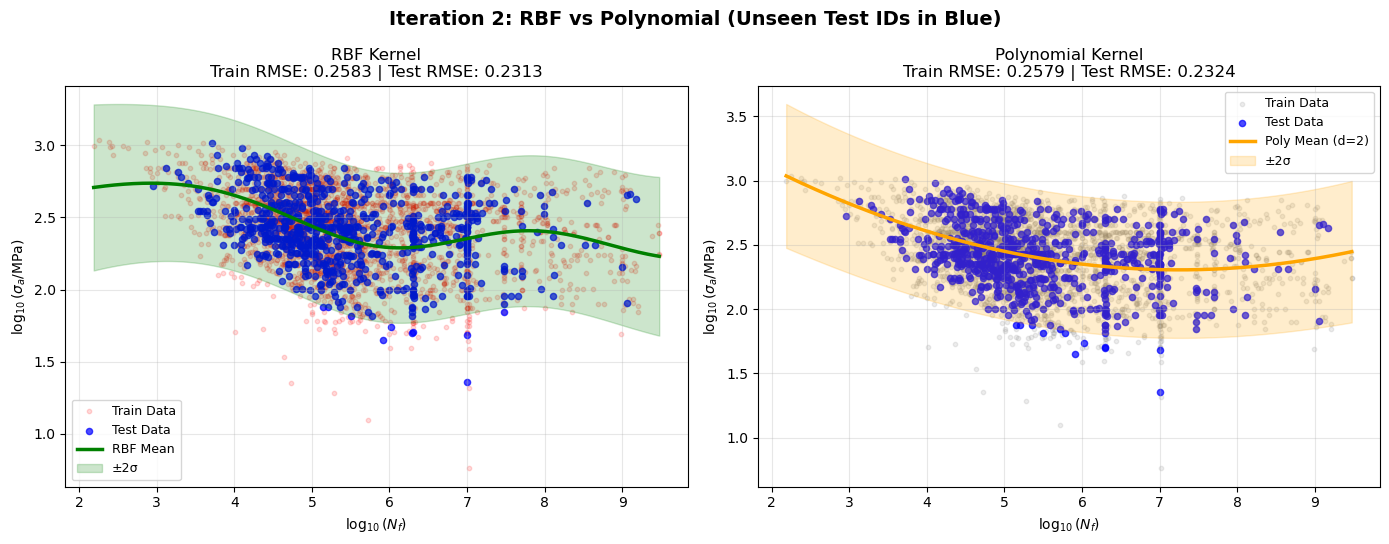

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, DotProduct


# Set up the kernels
# 1. RBF Kernel (Smooth, local interpolation)
rbf_kernel = (
    C(1.0, (1e-3, 10)) * RBF(length_scale=0.5, length_scale_bounds=(1.0, 8.0)) 
    + WhiteKernel(noise_level=0.3, noise_level_bounds=(0.05, 1.5))
)

poly_kernel = (
    C(1.0, (1e-3, 1e3)) * (DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) ** degree) 
    + WhiteKernel(noise_level=0.3, noise_level_bounds=(1e-3, 1.5))
)

# Prepare for the loop
unique_ids = subset["dataset_id"].dropna().unique()
rng_split = np.random.default_rng(42) # Seed to ensure the two iterations are reproducible

# ── RUN TWO ITERATIONS ────────────────────────────────────────────────────────
for iteration in range(1, 3):
    print(f"\n" + "="*70)
    print(f" ITERATION {iteration} - RESTARTING TRAINING DATA SPLIT")
    print("="*70)
    
    # 1. Fresh 80/20 Grouped Split
    shuffled_ids = rng_split.permutation(unique_ids)
    split_idx = int(0.8 * len(shuffled_ids))
    train_ids = shuffled_ids[:split_idx]
    test_ids  = shuffled_ids[split_idx:]
    
    train_df = subset[subset["dataset_id"].isin(train_ids)].copy()
    test_df  = subset[subset["dataset_id"].isin(test_ids)].copy()
    
    # Extract variables
    x_train = train_df["log10_life_N"].values.reshape(-1, 1)
    y_train = train_df["log10_stress"].values
    x_test  = test_df["log10_life_N"].values.reshape(-1, 1)
    y_test  = test_df["log10_stress"].values
    
    # 2. Normalize (Crucial for GPR to converge properly)
    x_mu, x_sd = x_train.mean(), x_train.std()
    y_mu, y_sd = y_train.mean(), y_train.std()
    
    xn_train = (x_train - x_mu) / x_sd
    yn_train = (y_train - y_mu) / y_sd
    xn_test  = (x_test - x_mu) / x_sd
    
    # Subsample training data to max 400 points to keep GPR fast
    idx_gpr = rng_split.choice(len(xn_train), size=min(400, len(xn_train)), replace=False)
    xn_train_sub = xn_train[idx_gpr]
    yn_train_sub = yn_train[idx_gpr]
    
    # 3. Fit Models
    gpr_rbf = GaussianProcessRegressor(kernel=rbf_kernel, n_restarts_optimizer=5, random_state=42)
    gpr_rbf.fit(xn_train_sub, yn_train_sub)
    
    gpr_poly = GaussianProcessRegressor(kernel=poly_kernel, n_restarts_optimizer=5, random_state=42)
    gpr_poly.fit(xn_train_sub, yn_train_sub)
    ## Printing optimised kernels
    
    print(" \nOptimized Kernels:")
    print(" \nRBF Kernel        ->", gpr_rbf.kernel_)
    print(" \nPolynomial Kernel ->", gpr_poly.kernel_)

   # 4. Predictions & Calculate RMSE
    # RBF
    mu_n_train_rbf, _ = gpr_rbf.predict(xn_train, return_std=True)
    mu_n_test_rbf, _  = gpr_rbf.predict(xn_test, return_std=True)
    train_rmse_rbf = np.sqrt(mean_squared_error(y_train, mu_n_train_rbf * y_sd + y_mu))
    test_rmse_rbf  = np.sqrt(mean_squared_error(y_test, mu_n_test_rbf * y_sd + y_mu))
    
    # Polynomial
    mu_n_train_poly, _ = gpr_poly.predict(xn_train, return_std=True)
    mu_n_test_poly, _  = gpr_poly.predict(xn_test, return_std=True)
    train_rmse_poly = np.sqrt(mean_squared_error(y_train, mu_n_train_poly * y_sd + y_mu))
    test_rmse_poly  = np.sqrt(mean_squared_error(y_test, mu_n_test_poly * y_sd + y_mu))
    print("="*60)
    print(f"\n RBF Kernel        -> Train RMSE: {train_rmse_rbf:.4f} | Test RMSE: {test_rmse_rbf:.4f}")
    print(f"\n Polynomial Kernel -> Train RMSE: {train_rmse_poly:.4f} | Test RMSE: {test_rmse_poly:.4f}")
    print("="*60)
    print()
    # 5. Plotting Side-by-Side
    x_line = np.linspace(subset["log10_life_N"].min(), subset["log10_life_N"].max(), 300)
    xn_line = (x_line.reshape(-1, 1) - x_mu) / x_sd
    
    # RBF line points
    mu_n_rbf_line, std_n_rbf_line = gpr_rbf.predict(xn_line, return_std=True)
    mu_rbf_line  = mu_n_rbf_line * y_sd + y_mu
    std_rbf_line = std_n_rbf_line * y_sd
    
    # Poly line points
    mu_n_poly_line, std_n_poly_line = gpr_poly.predict(xn_line, return_std=True)
    mu_poly_line  = mu_n_poly_line * y_sd + y_mu
    std_poly_line = std_n_poly_line * y_sd
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle(f"Iteration {iteration}: RBF vs Polynomial (Unseen Test IDs in Blue)", fontsize=14, fontweight="bold")
    
    # --- RBF Subplot ---
    ax = axes[0]
    ax.scatter(x_train, y_train, alpha=0.15, color="r", s=10, label="Train Data")
    ax.scatter(x_test, y_test, alpha=0.7, color="blue", s=20, label="Test Data")
    ax.plot(x_line, mu_rbf_line, color="green", lw=2.5, label="RBF Mean")
    ax.fill_between(x_line, mu_rbf_line - 2*std_rbf_line, mu_rbf_line + 2*std_rbf_line, alpha=0.2, color="green", label="±2σ")
    ax.set_title(f"RBF Kernel\nTrain RMSE: {train_rmse_rbf:.4f} | Test RMSE: {test_rmse_rbf:.4f}")
    ax.set_xlabel(r"$\log_{10}(N_f)$")
    ax.set_ylabel(r"$\log_{10}(\sigma_a / \mathrm{MPa})$")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # --- Polynomial Subplot ---
    ax = axes[1]
    ax.scatter(x_train, y_train, alpha=0.15, color="gray", s=10, label="Train Data")
    ax.scatter(x_test, y_test, alpha=0.7, color="blue", s=20, label="Test Data")
    ax.plot(x_line, mu_poly_line, color="orange", lw=2.5, label=f"Poly Mean (d={degree})")
    ax.fill_between(x_line, mu_poly_line - 2*std_poly_line, mu_poly_line + 2*std_poly_line, alpha=0.2, color="orange", label="±2σ")
    ax.set_title(f"Polynomial Kernel\nTrain RMSE: {train_rmse_poly:.4f} | Test RMSE: {test_rmse_poly:.4f}")
    ax.set_xlabel(r"$\log_{10}(N_f)$")
    ax.set_ylabel(r"$\log_{10}(\sigma_a / \mathrm{MPa})$")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("RBF and Poly.png")
    plt.show()

385

## Predicting 

### MLE, Bayesian ,GPR Trained on Whole data set tested on random Sampling.

In [25]:
# ── Prediction cell: input life → get stress from all three methods ────────────
import numpy as np

# Input: enter the fatigue life you want to predict stress for
N_predict = 1e6   # ← change this value (number of cycles)

log10_N = np.log10(N_predict)

# ── MLE prediction ────────────────────────────────────────────────────────────
log10_sigma_mle = log10_A + B_basquin * log10_N
sigma_mle_pred  = 10**log10_sigma_mle

# ── Bayesian prediction (posterior predictive with noise) ─────────────────────
post = trace.posterior

log10_A_samps = post["log10_A"].values.flatten()
B_samps       = post["B"].values.flatten()

# If your model includes noise (recommended)
if "sigma" in post:
    sigma_samps = post["sigma"].values.flatten()
else:
    sigma_samps = np.zeros_like(log10_A_samps)

# Posterior predictive (includes noise → IMPORTANT)
log10_sigma_bayes_samples = (
    log10_A_samps + B_samps * log10_N +
    np.random.normal(0, sigma_samps)
)

log10_sigma_bayes_mean = log10_sigma_bayes_samples.mean()
log10_sigma_bayes_std  = log10_sigma_bayes_samples.std()

sigma_bayes_mean = 10**log10_sigma_bayes_mean
sigma_bayes_low  = 10**(log10_sigma_bayes_mean - 2*log10_sigma_bayes_std)
sigma_bayes_high = 10**(log10_sigma_bayes_mean + 2*log10_sigma_bayes_std)

# ── GPR prediction ────────────────────────────────────────────────────────────
log10_N_norm = (log10_N - x_mu) / x_sd
mu_n_pred, std_n_pred = gpr.predict([[log10_N_norm]], return_std=True)

# FIX: use .item() instead of float()
log10_sigma_gpr     = mu_n_pred.item() * y_sd + y_mu
log10_sigma_gpr_std = std_n_pred.item() * y_sd

sigma_gpr_mean = 10**log10_sigma_gpr
sigma_gpr_low  = 10**(log10_sigma_gpr - 2*log10_sigma_gpr_std)
sigma_gpr_high = 10**(log10_sigma_gpr + 2*log10_sigma_gpr_std)

# ── Print results ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"Input: N_f = {N_predict:.2e} cycles")
print(f"       log10(N_f) = {log10_N:.4f}")
print("=" * 55)

print(f"\n{'Method':<12}  {'Stress (MPa)':>14}  {'95% interval'}")
print("-" * 55)

print(f"{'MLE':<12}  {sigma_mle_pred:>10.2f} MPa  (no uncertainty)")

print(f"{'Bayesian':<12}  {sigma_bayes_mean:>10.2f} MPa  "
      f"[{sigma_bayes_low:.2f}, {sigma_bayes_high:.2f}]")

print(f"{'GPR':<12}  {sigma_gpr_mean:>10.2f} MPa  "
      f"[{sigma_gpr_low:.2f}, {sigma_gpr_high:.2f}]")

print(f"\nAll three in stress (MPa):")
print(f"  MLE      σ = {sigma_mle_pred:.2f} MPa  (point estimate)")
print(f"  Bayesian σ = {sigma_bayes_mean:.2f} MPa  "
      f"(95% CI: [{sigma_bayes_low:.2f}, {sigma_bayes_high:.2f}])")
print(f"  GPR      σ = {sigma_gpr_mean:.2f} MPa  "
      f"(95% CI: [{sigma_gpr_low:.2f}, {sigma_gpr_high:.2f}])")

Input: N_f = 1.00e+06 cycles
       log10(N_f) = 6.0000

Method          Stress (MPa)  95% interval
-------------------------------------------------------
MLE               247.51 MPa  (no uncertainty)
Bayesian          247.45 MPa  [242.40, 252.61]
GPR               211.91 MPa  [64.79, 693.06]

All three in stress (MPa):
  MLE      σ = 247.51 MPa  (point estimate)
  Bayesian σ = 247.45 MPa  (95% CI: [242.40, 252.61])
  GPR      σ = 211.91 MPa  (95% CI: [64.79, 693.06])


### GPR with RBF and Polynomial Kernel Trained and tested by  splitting  data .

In [22]:
# ── Prediction for N = 1e6 cycles (Split-trained GPR) ─────────────────────────

N_predict = 1e6
log10_N = np.log10(N_predict)

# Normalize using current training split stats
log10_N_norm = (log10_N - x_mu) / x_sd

# --- RBF Prediction ---
mu_rbf_n, std_rbf_n = gpr_rbf.predict([[log10_N_norm]], return_std=True)

log10_sigma_rbf     = mu_rbf_n.item() * y_sd + y_mu
log10_sigma_rbf_std = std_rbf_n.item() * y_sd

sigma_rbf_mean = 10**log10_sigma_rbf
sigma_rbf_low  = 10**(log10_sigma_rbf - 2*log10_sigma_rbf_std)
sigma_rbf_high = 10**(log10_sigma_rbf + 2*log10_sigma_rbf_std)

# --- Polynomial Prediction ---
mu_poly_n, std_poly_n = gpr_poly.predict([[log10_N_norm]], return_std=True)

log10_sigma_poly     = mu_poly_n.item() * y_sd + y_mu
log10_sigma_poly_std = std_poly_n.item() * y_sd

sigma_poly_mean = 10**log10_sigma_poly
sigma_poly_low  = 10**(log10_sigma_poly - 2*log10_sigma_poly_std)
sigma_poly_high = 10**(log10_sigma_poly + 2*log10_sigma_poly_std)

# ── Print ────────────────────────────────────────────────────────────────────
print(f"\nPrediction for N = {N_predict:.2e} cycles (Iteration {iteration})")
print("-" * 60)
print(f"GPR (RBF)        σ = {sigma_rbf_mean:.2f} MPa  "
      f"[{sigma_rbf_low:.2f}, {sigma_rbf_high:.2f}]")

print(f"GPR (Polynomial) σ = {sigma_poly_mean:.2f} MPa  "
      f"[{sigma_poly_low:.2f}, {sigma_poly_high:.2f}]")
print("-" * 60)


Prediction for N = 1.00e+06 cycles (Iteration 2)
------------------------------------------------------------
GPR (RBF)        σ = 195.76 MPa  [59.22, 647.10]
GPR (Polynomial) σ = 223.89 MPa  [66.30, 756.07]
------------------------------------------------------------
